# Black Swan & Grey Swan - Recovery Pattern Analysis
**Scop:** Clasificam tiparul de recuperare al SP500 dupa crize majore (V-shape, U-shape, L-shape)  
**Abordare:** Fereastra de zile per eveniment, nu eveniment = 1 rand

## 1. Instalare si Import Librarii

In [3]:
# Instalare (ruleaza o singura data)
!pip install yfinance pandas-datareader fredapi

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

print('Librarii incarcate cu succes.')

  Using cached pandas_datareader-0.10.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached fredapi-0.5.2-py3-none-any.whl.metadata (5.0 kB)
Using cached pandas_datareader-0.10.0-py3-none-any.whl (109 kB)
Using cached fredapi-0.5.2-py3-none-any.whl (11 kB)
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ------- -------------------------------- 0.8/4.0 MB 11.2 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 24.1 MB/s  0:00:00

   ---------------------------------------- 0/3 [lxml]
   ------------- -------------------------- 1/3 [pandas-datareader]
   ---------------------------------------- 3/3 [fredapi]

Librarii incarcate cu succes.


## 2. Definitia Evenimentelor

Fiecare eveniment are:
- `start`: cu 60 de zile inainte de primul semnal al crizei
- `end`: 120 de zile dupa minimul atins
- `label`: tiparul de recuperare observat retrospectiv
- `category`: Grey Swan / Black Swan / Dragon King

In [4]:
EVENTS = [
    {
        'name'    : 'Dotcom Crash',
        'start'   : '2000-01-01',
        'end'     : '2002-10-31',
        'label'   : 'L-shape',
        'category': 'Grey Swan'
    },
    {
        'name'    : 'Global Financial Crisis',
        'start'   : '2008-01-01',
        'end'     : '2009-06-30',
        'label'   : 'U-shape',
        'category': 'Grey Swan'
    },
    {
        'name'    : 'European Debt Crisis',
        'start'   : '2011-04-01',
        'end'     : '2011-12-31',
        'label'   : 'V-shape',
        'category': 'Grey Swan'
    },
    {
        'name'    : 'Taper Tantrum',
        'start'   : '2013-04-01',
        'end'     : '2013-10-31',
        'label'   : 'V-shape',
        'category': 'Grey Swan'
    },
    {
        'name'    : 'China Devaluation',
        'start'   : '2015-06-01',
        'end'     : '2016-02-28',
        'label'   : 'V-shape',
        'category': 'Grey Swan'
    },
    {
        'name'    : 'Fed Rate Hikes 2022',
        'start'   : '2022-01-01',
        'end'     : '2022-12-31',
        'label'   : 'U-shape',
        'category': 'Grey Swan'
    },
    {
        'name'    : 'Liberation Day Tariffs',
        'start'   : '2025-02-01',
        'end'     : '2025-08-01',
        'label'   : 'V-shape',
        'category': 'Grey Swan'
    },
    {
        'name'    : 'COVID Crash',
        'start'   : '2020-01-15',
        'end'     : '2020-08-31',
        'label'   : 'V-shape',
        'category': 'Black Swan'
    },
    {
        'name'    : '9/11',
        'start'   : '2001-07-01',
        'end'     : '2001-12-31',
        'label'   : 'V-shape',
        'category': 'Black Swan'
    },
    {
        'name'    : 'Flash Crash',
        'start'   : '2010-04-01',
        'end'     : '2010-08-31',
        'label'   : 'V-shape',
        'category': 'Black Swan'
    },
]

print(f'Total evenimente definite: {len(EVENTS)}')
for e in EVENTS:
    print(f"  [{e['category']}] {e['name']} ({e['start']} -> {e['end']}) -> {e['label']}")

Total evenimente definite: 10
  [Grey Swan] Dotcom Crash (2000-01-01 -> 2002-10-31) -> L-shape
  [Grey Swan] Global Financial Crisis (2008-01-01 -> 2009-06-30) -> U-shape
  [Grey Swan] European Debt Crisis (2011-04-01 -> 2011-12-31) -> V-shape
  [Grey Swan] Taper Tantrum (2013-04-01 -> 2013-10-31) -> V-shape
  [Grey Swan] China Devaluation (2015-06-01 -> 2016-02-28) -> V-shape
  [Grey Swan] Fed Rate Hikes 2022 (2022-01-01 -> 2022-12-31) -> U-shape
  [Grey Swan] Liberation Day Tariffs (2025-02-01 -> 2025-08-01) -> V-shape
  [Black Swan] COVID Crash (2020-01-15 -> 2020-08-31) -> V-shape
  [Black Swan] 9/11 (2001-07-01 -> 2001-12-31) -> V-shape
  [Black Swan] Flash Crash (2010-04-01 -> 2010-08-31) -> V-shape


## 3. Descarcare Date Brute

Descarcam tot istoricul SP500 si VIX dintr-o singura comanda.  
Vom taia fereastra fiecarui eveniment ulterior.

In [5]:
# SP500 - indicele principal
sp500_raw = yf.download('^GSPC', start='1999-01-01', end='2025-09-01', auto_adjust=True)
sp500_raw = sp500_raw[['Close', 'Volume']].copy()
sp500_raw.columns = ['SP500_Close', 'SP500_Volume']

# VIX - indicele fricii
vix_raw = yf.download('^VIX', start='1999-01-01', end='2025-09-01', auto_adjust=True)
vix_raw = vix_raw[['Close']].copy()
vix_raw.columns = ['VIX']

# Unim intr-un singur DataFrame
market_data = sp500_raw.join(vix_raw, how='left')
market_data.index = pd.to_datetime(market_data.index)

print(f'Date incarcate: {market_data.index[0].date()} -> {market_data.index[-1].date()}')
print(f'Total zile de tranzactionare: {len(market_data)}')
market_data.tail()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Date incarcate: 1999-01-04 -> 2025-08-29
Total zile de tranzactionare: 6706


,SP500_Close,SP500_Volume,VIX
Date,,,
2025-08-25,6439.319824,4059070000,14.79
2025-08-26,6465.939941,4867680000,14.62
2025-08-27,6481.399902,4143680000,14.85
2025-08-28,6501.859863,4283760000,14.43
2025-08-29,6460.259766,4234840000,15.36


## 4. Feature Engineering

Calculam toate features pe intregul dataset.  
Vom taia pe ferestre dupa ce toate coloanele sunt gata.

In [6]:
df = market_data.copy()

# --- Features de pret si trend ---

# Retun zilnic procentual
df['Return_1d'] = df['SP500_Close'].pct_change()

# Return pe 5 zile (o saptamana) - captureaza momentum pe termen scurt
df['Return_5d'] = df['SP500_Close'].pct_change(5)

# Medii mobile - ne spun daca suntem in trend bullish sau bearish
df['MA50']  = df['SP500_Close'].rolling(50).mean()
df['MA200'] = df['SP500_Close'].rolling(200).mean()

# Distanta procentuala fata de MA50 si MA200
# Valoare negativa = suntem sub medie = trend bearish
df['Dist_MA50']  = (df['SP500_Close'] - df['MA50'])  / df['MA50']
df['Dist_MA200'] = (df['SP500_Close'] - df['MA200']) / df['MA200']

# Distanta procentuala fata de maximul din ultimele 252 de zile (1 an)
# Ne spune cat de adanc suntem in criza
df['Dist_52w_High'] = (df['SP500_Close'] - df['SP500_Close'].rolling(252).max()) / df['SP500_Close'].rolling(252).max()

# --- Features de volatilitate si frica ---

# Schimbarea VIX fata de ziua anterioara
df['VIX_Change'] = df['VIX'].pct_change()

# Volatilitate realizata pe 10 zile (deviatia standard a retururilor)
df['Realized_Vol_10d'] = df['Return_1d'].rolling(10).std() * np.sqrt(252)

# Raport volum curent vs medie 20 zile - spike de volum = panica sau capitulare
df['Volume_Ratio'] = df['SP500_Volume'] / df['SP500_Volume'].rolling(20).mean()

# Numar de zile consecutive de scadere
df['Consec_Down'] = (
    df['Return_1d']
    .lt(0)
    .groupby((df['Return_1d'].lt(0) != df['Return_1d'].lt(0).shift()).cumsum())
    .cumsum()
)

# --- RSI (Relative Strength Index) ---
# Sub 30 = oversold (piata exagerata la vanzare)
# Peste 70 = overbought
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI'] = compute_rsi(df['SP500_Close'])

print('Features calculate:')
feature_cols = ['Return_1d', 'Return_5d', 'Dist_MA50', 'Dist_MA200',
                'Dist_52w_High', 'VIX', 'VIX_Change', 'Realized_Vol_10d',
                'Volume_Ratio', 'Consec_Down', 'RSI']
for f in feature_cols:
    print(f'  {f}')

df[feature_cols].tail()

Features calculate:
  Return_1d
  Return_5d
  Dist_MA50
  Dist_MA200
  Dist_52w_High
  VIX
  VIX_Change
  Realized_Vol_10d
  Volume_Ratio
  Consec_Down
  RSI


,Return_1d,Return_5d,Dist_MA50,Dist_MA200,Dist_52w_High,VIX,VIX_Change,Realized_Vol_10d,Volume_Ratio,Consec_Down,RSI
Date,,,,,,,,,,,
2025-08-25,-0.004266,-0.001524,0.025789,0.082544,-0.004517,14.79,0.040084,0.111210,0.825431,1,66.137641
2025-08-26,0.004134,0.008511,0.028428,0.086395,-0.000402,14.62,-0.011494,0.097574,0.991968,0,64.566618
2025-08-27,0.002391,0.013387,0.029419,0.088488,0.000000,14.85,0.015732,0.096965,0.855156,0,66.622735
2025-08-28,0.003157,0.020673,0.030968,0.091439,0.000000,14.43,-0.028283,0.098064,0.900733,0,64.181302
2025-08-29,-0.006398,-0.001028,0.022817,0.084033,-0.006398,15.36,0.064449,0.102945,0.905607,1,60.287184


## 5. Construirea Dataset-ului Final

Taiem fereastra fiecarui eveniment si adaugam:
- `event_name`: numele crizei
- `category`: Grey / Black Swan
- `label`: V / U / L shape
- `day_relative`: ziua relativa in fereastra (0 = primul semnal)

In [7]:
all_windows = []

for event in EVENTS:
    # Taiem fereastra
    mask   = (df.index >= event['start']) & (df.index <= event['end'])
    window = df.loc[mask].copy()

    if len(window) == 0:
        print(f"ATENTIE: Nu s-au gasit date pentru {event['name']}")
        continue

    # Adaugam metadate
    window['event_name']  = event['name']
    window['category']    = event['category']
    window['label']       = event['label']
    window['day_relative'] = range(len(window))

    all_windows.append(window)
    print(f"{event['name']}: {len(window)} zile | Label: {event['label']}")

# Combinam toate evenimentele
dataset = pd.concat(all_windows)
dataset = dataset.dropna(subset=feature_cols)

print(f'\nDataset final: {len(dataset)} randuri')
print(f'Distributia labelurilor:')
print(dataset['label'].value_counts())

Dotcom Crash: 711 zile | Label: L-shape
Global Financial Crisis: 377 zile | Label: U-shape
European Debt Crisis: 190 zile | Label: V-shape
Taper Tantrum: 151 zile | Label: V-shape
China Devaluation: 188 zile | Label: V-shape
Fed Rate Hikes 2022: 251 zile | Label: U-shape
Liberation Day Tariffs: 125 zile | Label: V-shape
COVID Crash: 159 zile | Label: V-shape
9/11: 123 zile | Label: V-shape
Flash Crash: 106 zile | Label: V-shape

Dataset final: 2381 randuri
Distributia labelurilor:
label
V-shape    1042
L-shape     711
U-shape     628
Name: count, dtype: int64


## 6. Vizualizare Evenimente

Plotam SP500 cu evenimentele marcate pentru a verifica ca am capturat perioadele corecte.

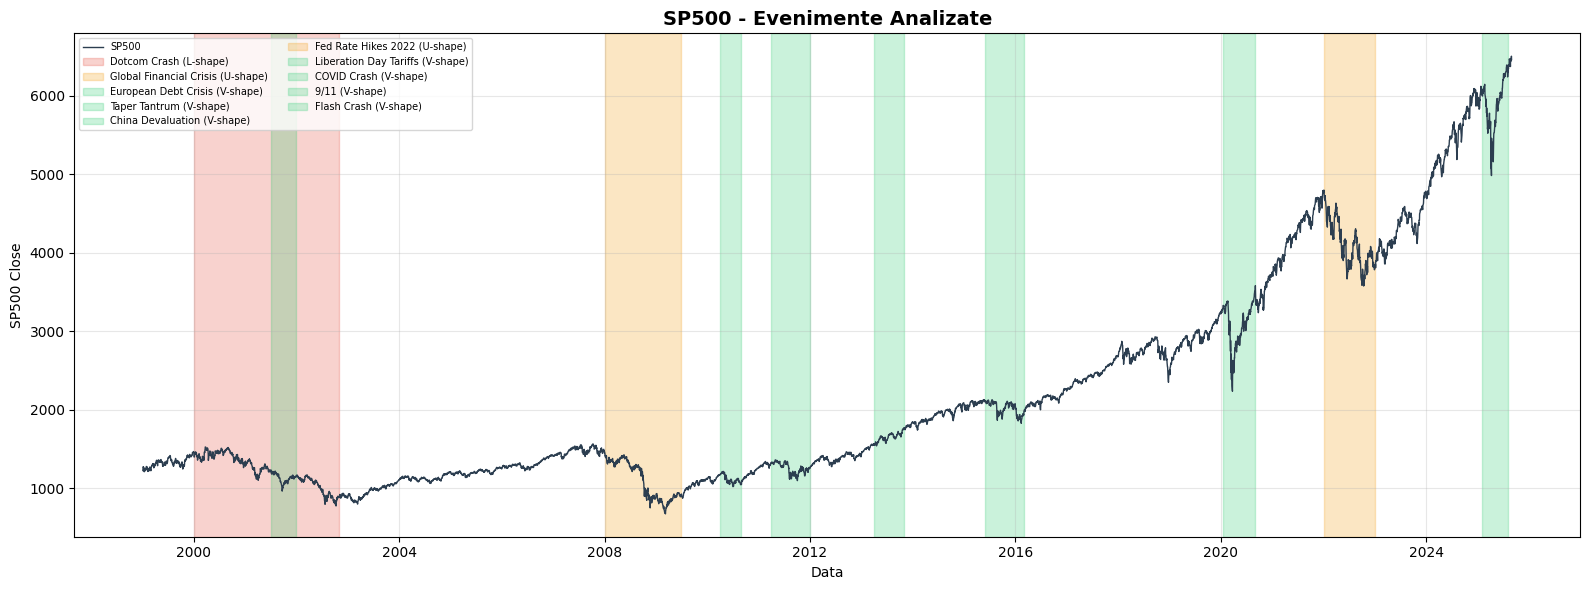

In [8]:
colors = {'V-shape': '#2ecc71', 'U-shape': '#f39c12', 'L-shape': '#e74c3c'}

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df.index, df['SP500_Close'], color='#2c3e50', linewidth=1, label='SP500')

for event in EVENTS:
    color = colors[event['label']]
    ax.axvspan(
        pd.to_datetime(event['start']),
        pd.to_datetime(event['end']),
        alpha=0.25,
        color=color,
        label=f"{event['name']} ({event['label']})"
    )

ax.set_title('SP500 - Evenimente Analizate', fontsize=14, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('SP500 Close')
ax.legend(loc='upper left', fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Train / Test Split

**Regula importanta:** Nu amestecam zilele aleator.  
Antrenam pe evenimente vechi, testam pe evenimente recente.  
Asa verificam daca modelul generalizeaza pe crize pe care nu le-a vazut.

In [11]:
# --- Tratam Dotcom Crash special ---
# Primele 511 zile -> train (faza de cadere + inceput de stagnare)
# Ultimele 200 zile -> test  (faza L-shape confirmata)

dotcom_all  = dataset[dataset['event_name'] == 'Dotcom Crash'].copy()
dotcom_train = dotcom_all.iloc[:-200]
dotcom_test  = dotcom_all.iloc[-200:]

print(f'Dotcom train: {len(dotcom_train)} zile')
print(f'Dotcom test:  {len(dotcom_test)} zile')

# --- Restul evenimentelor ---
TRAIN_EVENTS = [
    'Global Financial Crisis',
    'European Debt Crisis',
    'Taper Tantrum',
    'China Devaluation',
    '9/11',
    'Flash Crash'
]

TEST_EVENTS = [
    'Fed Rate Hikes 2022',
    'COVID Crash',
    'Liberation Day Tariffs'
]

train_rest = dataset[dataset['event_name'].isin(TRAIN_EVENTS)]
test_rest  = dataset[dataset['event_name'].isin(TEST_EVENTS)]

# --- Combinam ---
train_df = pd.concat([dotcom_train, train_rest])
test_df  = pd.concat([dotcom_test,  test_rest])

X_train = train_df[feature_cols]
y_train = train_df['label']

X_test  = test_df[feature_cols]
y_test  = test_df['label']

print(f'\nTrain: {len(X_train)} zile')
print(f'Test:  {len(X_test)} zile')
print(f'\nDistributie train:')
print(y_train.value_counts())
print(f'\nDistributie test:')
print(y_test.value_counts())

Dotcom train: 511 zile
Dotcom test:  200 zile

Train: 1646 zile
Test:  735 zile

Distributie train:
label
V-shape    758
L-shape    511
U-shape    377
Name: count, dtype: int64

Distributie test:
label
V-shape    284
U-shape    251
L-shape    200
Name: count, dtype: int64


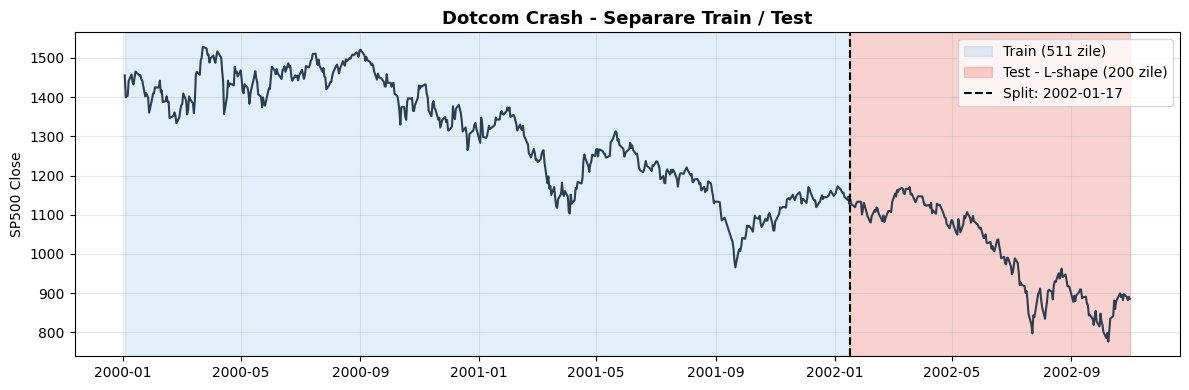

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))

# Pretul SP500 in fereastra Dotcom
dotcom_prices = df.loc[dotcom_all.index, 'SP500_Close']
ax.plot(dotcom_prices.index, dotcom_prices.values, color='#2c3e50', linewidth=1.5)

# Zona train (albastru)
ax.axvspan(
    dotcom_train.index[0], dotcom_train.index[-1],
    alpha=0.15, color='#3498db', label=f'Train ({len(dotcom_train)} zile)'
)

# Zona test (portocaliu)
ax.axvspan(
    dotcom_test.index[0], dotcom_test.index[-1],
    alpha=0.25, color='#e74c3c', label=f'Test - L-shape ({len(dotcom_test)} zile)'
)

# Linia de separare
split_date = dotcom_test.index[0]
ax.axvline(split_date, color='black', linestyle='--', linewidth=1.5, label=f'Split: {split_date.date()}')

ax.set_title('Dotcom Crash - Separare Train / Test', fontsize=13, fontweight='bold')
ax.set_ylabel('SP500 Close')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Salvare Dataset
Salvam dataset-ul pentru a-l folosi in notebook-urile de modelare.

In [13]:
dataset.to_csv('black_swan_dataset.csv')
print(f'Dataset salvat: black_swan_dataset.csv')
print(f'Shape: {dataset.shape}')
dataset[feature_cols + ['event_name', 'category', 'label']].head(10)

Dataset salvat: black_swan_dataset.csv
Shape: (2381, 19)


,Return_1d,Return_5d,Dist_MA50,Dist_MA200,Dist_52w_High,VIX,VIX_Change,Realized_Vol_10d,Volume_Ratio,Consec_Down,RSI,event_name,category,label
Date,,,,,,,,,,,,,,
2000-01-03,-0.009549,-0.001290,0.039790,0.080542,-0.009549,24.209999,-0.017451,0.109133,1.048062,1,69.896534,Dotcom Crash,Grey Swan,L-shape
2000-01-04,-0.038345,-0.039954,-0.001475,0.038714,-0.047528,27.010000,0.115655,0.232708,1.129040,2,48.700354,Dotcom Crash,Grey Swan,L-shape
2000-01-05,0.001922,-0.041921,-0.001102,0.040170,-0.045697,26.410000,-0.022214,0.223937,1.214662,0,45.899135,Dotcom Crash,Grey Swan,L-shape
2000-01-06,0.000956,-0.041667,-0.001876,0.040644,-0.044785,25.730000,-0.025748,0.223521,1.213088,0,44.223346,Dotcom Crash,Grey Swan,L-shape
2000-01-07,0.027090,-0.018908,0.023057,0.068235,-0.018908,21.719999,-0.155849,0.254702,1.352938,0,56.066706,Dotcom Crash,Grey Swan,L-shape
2000-01-10,0.011190,0.001635,0.032817,0.079490,-0.007929,21.709999,-0.000460,0.262027,1.170799,0,60.875318,Dotcom Crash,Grey Swan,L-shape
2000-01-11,-0.013063,0.027969,0.018234,0.064882,-0.020888,22.500000,0.036389,0.270267,1.112715,1,51.383872,Dotcom Crash,Grey Swan,L-shape
2000-01-12,-0.004386,0.021496,0.012648,0.059696,-0.025183,22.840000,0.015111,0.269050,1.072610,2,48.973326,Dotcom Crash,Grey Swan,L-shape
2000-01-13,0.012170,0.032940,0.023496,0.071944,-0.013320,21.709999,-0.049475,0.278304,1.134240,0,47.649062,Dotcom Crash,Grey Swan,L-shape
